<a href="https://colab.research.google.com/github/rajakchhavi1-prog/Credit-Risk-Modelling/blob/main/Quick_commerce_funnel_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv("/content/sample_data/orders.csv")
order_products = pd.read_csv("/content/sample_data/order_products__prior.csv")
products = pd.read_csv("/content/sample_data/products.csv")

In [3]:
df = order_products.merge(orders, on="order_id")
df = df.merge(products, on="product_id")

print(df.head())

   order_id  product_id  add_to_cart_order  reordered  user_id eval_set  \
0         2       33120                1.0        1.0   202279    prior   
1         2       28985                2.0        1.0   202279    prior   
2         2        9327                3.0        0.0   202279    prior   
3         2       45918                4.0        1.0   202279    prior   
4         2       30035                5.0        0.0   202279    prior   

   order_number  order_dow  order_hour_of_day  days_since_prior_order  \
0             3          5                  9                     8.0   
1             3          5                  9                     8.0   
2             3          5                  9                     8.0   
3             3          5                  9                     8.0   
4             3          5                  9                     8.0   

            product_name  aisle_id  department_id  
0     Organic Egg Whites        86             16  
1  Mic

In [4]:
total_users = df["user_id"].nunique()
print("Total Users:", total_users)


Total Users: 177768


In [5]:
orders_per_user = df.groupby("user_id")["order_id"].nunique()

print("Average Orders per User:", orders_per_user.mean())

Average Orders per User: 4.404094100175509


In [6]:
# funnel construction
# user with atleast one order
stage1_users = df["user_id"].nunique()

In [7]:
#Users with multiple products (add-to-cart proxy

cart_users = df.groupby("order_id").size()
cart_users = cart_users[cart_users > 1]

stage2_users = df[df["order_id"].isin(cart_users.index)]["user_id"].nunique()

In [8]:
# repested users
repeat_users = orders_per_user[orders_per_user > 1]

stage3_users = repeat_users.count()

In [9]:
# conversion rate

funnel = pd.DataFrame({
    "Stage": [
        "Visited / Ordered Once",
        "Added Multiple Items",
        "Repeat Customer"
    ],
    "Users": [
        stage1_users,
        stage2_users,
        stage3_users
    ]
})

funnel["Conversion Rate"] = funnel["Users"] / funnel["Users"].shift(1)
funnel.iloc[0,2] = 1

print(funnel)

                    Stage   Users  Conversion Rate
0  Visited / Ordered Once  177768         1.000000
1    Added Multiple Items  173913         0.978314
2         Repeat Customer  133252         0.766199


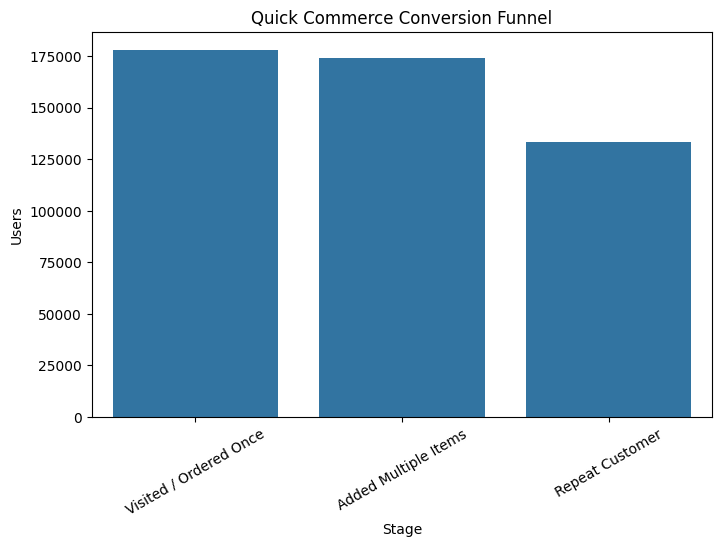

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(x="Stage", y="Users", data=funnel)

plt.title("Quick Commerce Conversion Funnel")
plt.xticks(rotation=30)
plt.show()

In [11]:
# category impact on order

top_categories = df.groupby("product_name")["order_id"].count().sort_values(ascending=False).head(10)

print(top_categories)

product_name
Banana                    115427
Bag of Organic Bananas     92292
Organic Strawberries       64744
Organic Baby Spinach       58622
Organic Hass Avocado       51938
Organic Avocado            42657
Large Lemon                37059
Strawberries               34850
Limes                      34093
Organic Whole Milk         33526
Name: order_id, dtype: int64


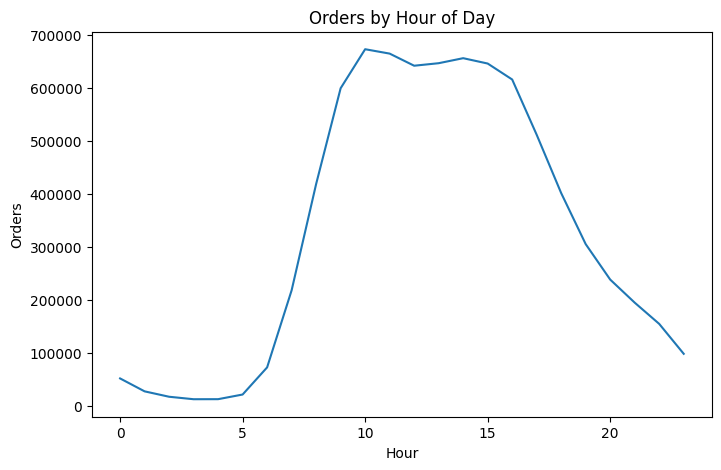

In [12]:
# time of order analysis

orders_by_hour = df.groupby("order_hour_of_day")["order_id"].count()

plt.figure(figsize=(8,5))
orders_by_hour.plot(kind="line")

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.show()

In [13]:
# repeat purchase probability

repeat_rate = df["reordered"].mean()

print("Average Reorder Probability:", repeat_rate)

Average Reorder Probability: 0.5892105967028157


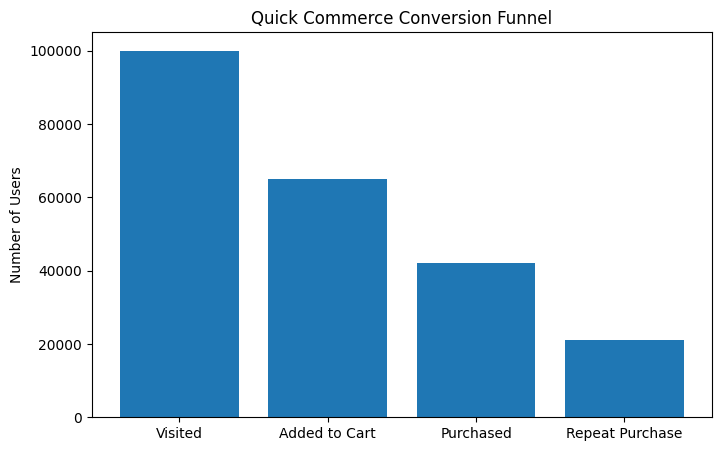

In [14]:
import matplotlib.pyplot as plt

stages = [
    "Visited",
    "Added to Cart",
    "Purchased",
    "Repeat Purchase"
]

users = [100000, 65000, 42000, 21000]

plt.figure(figsize=(8,5))
plt.bar(stages, users)

plt.title("Quick Commerce Conversion Funnel")
plt.ylabel("Number of Users")

plt.show()

In [15]:
import pandas as pd

funnel_df = pd.DataFrame({
    "stage": ["Visit", "Add to Cart", "Purchase", "Repeat"],
    "users": [100000, 65000, 42000, 21000]
})

funnel_df["conversion"] = funnel_df["users"].pct_change()

print(funnel_df)

         stage   users  conversion
0        Visit  100000         NaN
1  Add to Cart   65000   -0.350000
2     Purchase   42000   -0.353846
3       Repeat   21000   -0.500000


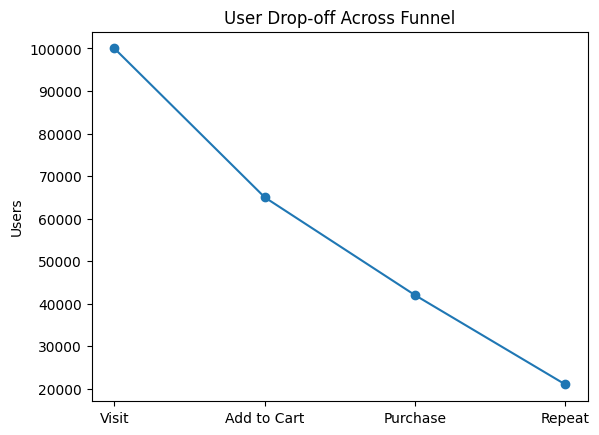

In [16]:
plt.plot(funnel_df["stage"], funnel_df["users"], marker="o")

plt.title("User Drop-off Across Funnel")
plt.ylabel("Users")
plt.show()

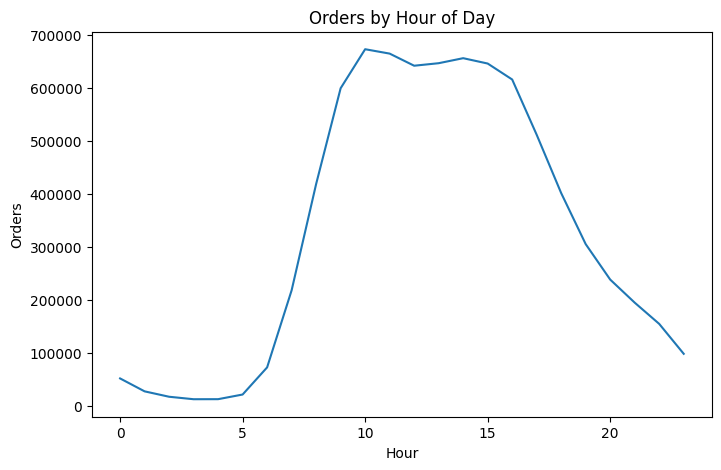

In [17]:
orders_by_hour = df.groupby("order_hour_of_day")["order_id"].count()

orders_by_hour.plot(kind="line", figsize=(8,5))

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.show()

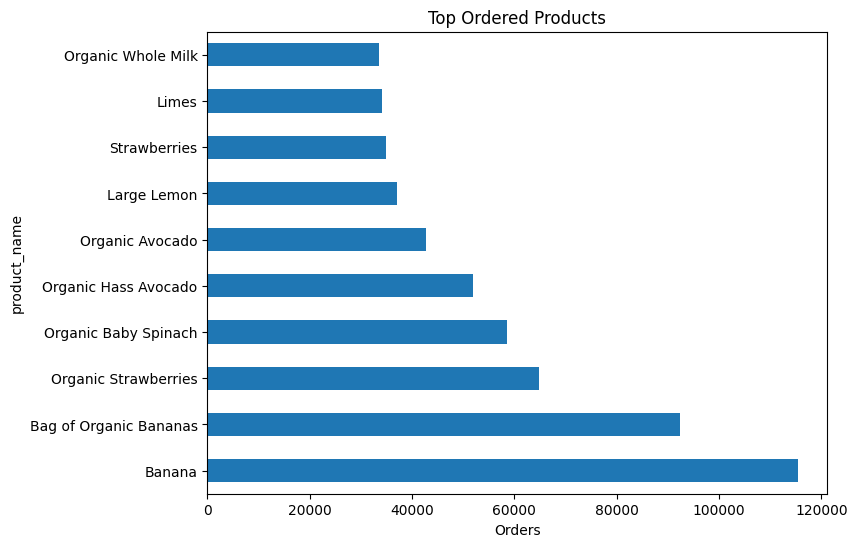

In [18]:
top_products = df["product_name"].value_counts().head(10)

top_products.plot(kind="barh", figsize=(8,6))

plt.title("Top Ordered Products")
plt.xlabel("Orders")
plt.show()

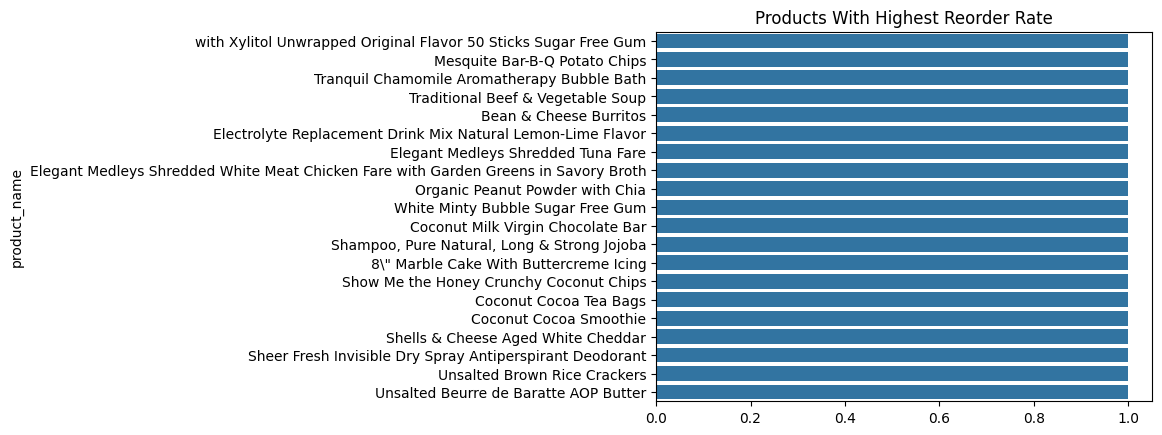

In [19]:
import seaborn as sns

reorder_rate = df.groupby("product_name")["reordered"].mean().sort_values(ascending=False).head(20)

sns.barplot(x=reorder_rate.values, y=reorder_rate.index)

plt.title("Products With Highest Reorder Rate")
plt.show()

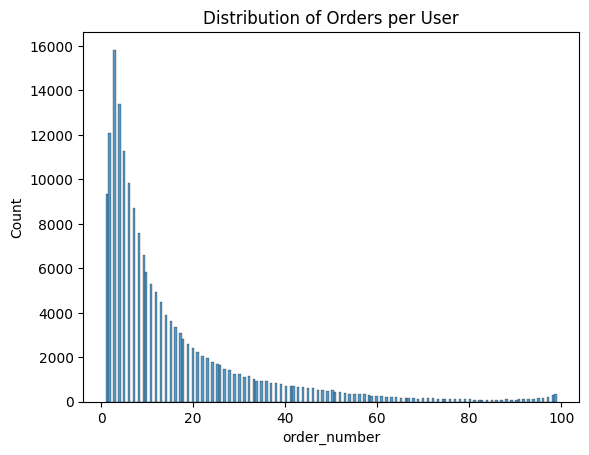

In [20]:
cohort = df.groupby(["user_id"])["order_number"].max()

sns.histplot(cohort)

plt.title("Distribution of Orders per User")
plt.show()

In [21]:
# Cohort Retention Analysis

# This shows how long users stay active after signup.

first_order = orders.groupby("user_id")["order_number"].min()

In [22]:
orders["cohort"] = orders.groupby("user_id")["order_number"].transform("min")

In [23]:
cohort_data = orders.groupby(["cohort", "order_number"])["user_id"].nunique()

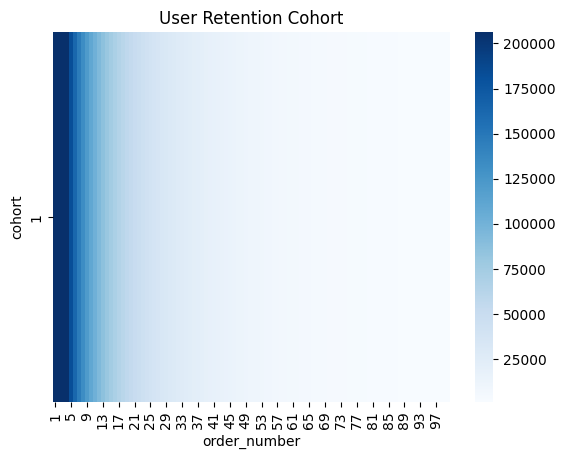

In [25]:
import seaborn as sns

cohort_table = cohort_data.unstack(level='order_number')
sns.heatmap(cohort_table, cmap="Blues")

plt.title("User Retention Cohort")
plt.show()

In [26]:
# Logistic Regression (Predict Repeat Users)

# Use Python ML to predict whether a user will return.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [27]:
features = df.groupby("user_id").agg({

"order_number":"max",
"reordered":"mean",
"product_id":"count"

})

In [29]:
features["repeat_user"] = (features["order_number"] > 1).astype(int)
X = features.drop("repeat_user", axis=1)
y = features["repeat_user"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [30]:
model.score(X_test,y_test)

1.0

In [31]:
#A/B Testing Simulation
#Imagine testing:
#New homepage recommendation feature
#Goal:
#Increase repeat purchases

In [32]:
control_conversion = 0.32
treatment_conversion = 0.36

In [33]:
from statsmodels.stats.proportion import proportions_ztest

In [34]:
count = [360, 320]
nobs = [1000,1000]

z,p = proportions_ztest(count,nobs)

print(p)

0.05900752319680951
